# Comparação de Métodos de Interpolação de Curvas de Carga
Este notebook demonstra a diferença visual e matemática entre a **Interpolação Linear** e a **Interpolação PCHIP** aplicadas a uma curva de carga típica do OpenDSS.

## 1. O Problema da Resolução
Dados de medição ou curvas típicas de concessionárias geralmente vêm com resolução de **1 hora**. Para simulações precisas (como análise de impacto de carregadores de veículos elétricos), precisamos de resoluções maiores, como **10 minutos**.
O processo de estimar os valores intermediários entre duas horas conhecidas é chamado de **interpolação**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, PchipInterpolator

# Extraímos as primeiras 12 horas de uma curva real do arquivo CurvaCarga_20250139_ADT01C2.dss
# O eixo X representa as horas (0 a 12)
x_orig = np.arange(13)

# O eixo Y representa o multiplicador da curva de carga (PU)
y_orig = np.array([
    0.8065, 0.7937, 0.7968, 0.8219, 0.8461, 0.8025, 
    0.7805, 0.7007, 0.7108, 0.7016, 0.6769, 0.6152, 0.5861
])

## 2. Métodos de Interpolação

### Interpolação Linear
A interpolação linear simplesmente traça uma **reta** entre um ponto e o próximo. 
- **Vantagem:** Simples e computacionalmente barata.
- **Desvantagem:** Cria transições bruscas ("quinas") nos pontos de dados, formando um desenho de "serrote". O consumo de energia no mundo real é um processo contínuo (impulsionado pela inércia térmica e inércia de motores) e raramente possui essas quebras instantâneas de tendência.

### Interpolação PCHIP
*Piecewise Cubic Hermite Interpolating Polynomial* (PCHIP) utiliza polinômios de grau 3 para conectar os pontos, garantindo que a curva seja suave.
- **Vantagem:** Produz curvas contínuas e esteticamente/fisicamente agradáveis. Diferente da Spline Cúbica tradicional, o PCHIP **preserva a monotonicidade**. Isso significa que ele *nunca* vai criar um "pico falso" que ultrapasse o valor máximo medido, nem vai criar valores negativos (overshoot/undershoot) em vales, o que é fundamental para evitar anomalias em grandezas como potência elétrica.

In [2]:
# Criando um novo eixo X para resolução de 10 minutos
# De 0 a 12 horas, com passos de 10/60 de hora (0.1666...)
x_10min = np.linspace(0, 12, 12 * 6 + 1)

# 1. Aplicando Interpolação Linear
interpolador_linear = interp1d(x_orig, y_orig, kind='linear')
y_linear = interpolador_linear(x_10min)

# 2. Aplicando Interpolação PCHIP
interpolador_pchip = PchipInterpolator(x_orig, y_orig)
y_pchip = interpolador_pchip(x_10min)

## 3. Visualização e Comparação
Vamos plotar os resultados para entender o impacto visual da escolha do método.

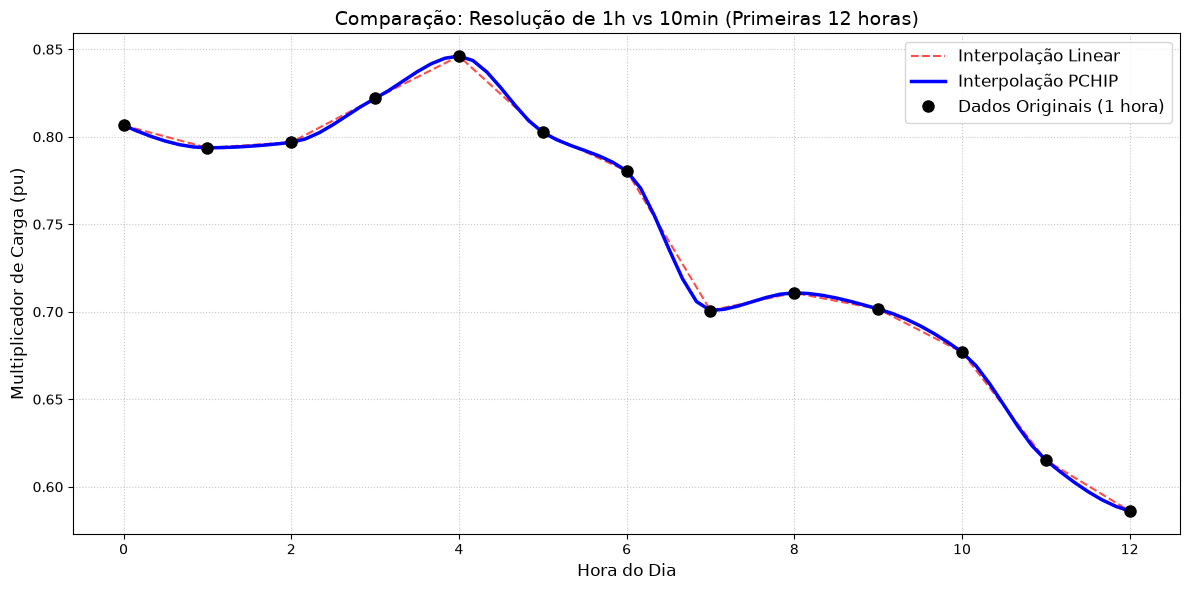

In [3]:
plt.figure(figsize=(12, 6))

# Plot das interpolações
plt.plot(x_10min, y_linear, '--', label='Interpolação Linear', color='red', alpha=0.7)
plt.plot(x_10min, y_pchip, '-', label='Interpolação PCHIP', color='blue', linewidth=2.5)

# Plot dos pontos originais
plt.plot(x_orig, y_orig, 'ko', label='Dados Originais (1 hora)', markersize=8, zorder=5)

plt.title('Comparação: Resolução de 1h vs 10min (Primeiras 12 horas)', fontsize=14)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Multiplicador de Carga (pu)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Conclusão
Observe o pico local por volta das **4h da manhã** e o vale ao redor das **8h**.
A **Interpolação Linear** (vermelha) desenha picos afiados e quinas que não condizem com a realidade do consumo elétrico. A **Interpolação PCHIP** (azul) contorna esses mesmos pontos originais de maneira perfeitamente suave, modelando uma curva muito mais condizente com a curva de carga natural.